## Stokes Flow in Periodic Channel with Robin boundary.

In [28]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "none"#"last_expr_or_assign"

import numpy as np
import matplotlib.pyplot as plt
from util.logger import EventTracker
from util.basis_scaled import *
from util.plot_tools import *
from boundary_solvers.gauss_grid_2d import StokesDirichletProblem
from scipy.io import loadmat
import matplotlib.pyplot as plt
from util.interp import PiecewiseInterp2D
from boundary_solvers.gauss_grid_2d import TrapezGrid
from hmm.stokes import *
from hmm.stokes_deep import DeepMicroSolver, get_net
import matplotlib
from scipy.interpolate import interp1d
from architecture.session import fno_ver3, fno_ver4, fno_ver1, fno_ver2, egeofno_ver2, svdfno_ver2, svdfno_ver1, svdfno_ver3, egeofno_ver5, svdfno_ver4
import torch

#matplotlib.rcParams['text.usetex'] = False


#net_dir = "/mnt/data0/emastr/article_training_nodecay/"
net_dir = "/mnt/data0/emastr/training/article_training_hugedata/"
MESH_PATH = "/home/emastr/deep-micro-slip-model/data/mesh/"
figures_dir = "/home/emastr/deep-micro-slip-model/data/figures/"
simulation_dir = "/home/emastr/deep-micro-slip-model/data/stokes_fenics/"
#data_dir = "/home/emastr/deep-micro-slip-model/data/micro_geometries_boundcurv_repar_256_torch/data_big_clean.torch"
run_dir = "/home/emastr/deep-micro-slip-model/data/reference_2/"

#pretty_pyplot_layout()

## Multiscale Problem

We define a multiscale problem as follows. The PDE is a non-slip zero forcing Stokes flow Problem

\begin{equation}
\Delta u  - \nabla p = 0, \qquad \qquad \nabla \cdot u = 0   \qquad \text{inside}\quad \Omega
\end{equation}

with the boundary conditions

\begin{equation}
u = g,\qquad \text{on}\quad\partial\Omega
\end{equation}

the boundary is a two-dimensional pipe with corners at (0,-1) and (1,1), and a micro scale boundary:

In [29]:
i = 41-8#41-8#41-16#2+16*0#+16#2+16#2+16*3# 2+16#41 # 38 #41 #35 #11 #38 #22 
data, info = StokesData.load_from_matlab(f"{run_dir}run_{i}.mat")
data_0, _ = StokesData.load_from_matlab(f"{run_dir}run_{i}.mat")

data_big_domain = data
dom = data.dom
eval_pos = info["eval_pos"]
eps = info["eps"]
nper = info["nper"]
Lx = info["Lx"]
bbox = info["bbox"]
Uc = info['Uc']
Vc = info['Vc']
Uyc = info['Uyc']

x = np.linspace(bbox[0][0],bbox[0][1],Uc.shape[0])
y = np.linspace(bbox[1][0],bbox[1][1],Uc.shape[1])
X,Y = np.meshgrid(x,y)

pwlerp = PiecewiseInterp2D(x, y, Uc)
from architecture.session import egeofno_ver3, egeofno_ver2, egeofno_ver1, svdfno_ver2, svdfno_ver1, svdfno_ver3, fno_ver2
pwlerp_dy = PiecewiseInterp2D(x, y, Uyc)
pwlerp_alpha = lambda x: -pwlerp(x, np.ones_like(x)*eval_pos) / pwlerp_dy(x, np.ones_like(x)*eval_pos)
print(eps)

0.007742636826811269


### Load Network for evaluation

In [30]:
device = "cpu" # "cuda:0"
num_pts = 256
#net, net_settings = get_net(f"{net_dir}fnoskip_big_data_{40000}.Torch", 256, "cpu", "float")
net_type = 2# 0: egeofno, 1: svdfno, 2: fno_vanilla
# net_type 0 works well

if net_type == 0:
    net = egeofno_ver1(device=device)
    net_data = torch.load(f"{net_dir}fno_ver1_seed0_40000.Torch", map_location=torch.device(device))
elif net_type == 1:
    net = svdfno_ver2(device=device)
    net_data = torch.load(f"{net_dir}svdfno_ver2_seed0_40000.Torch", map_location=torch.device(device))
else:
    net = fno_ver3(device=device)
    net_data = torch.load(f"{net_dir}fno_vanilla_ver3_seed0_40000.Torch", map_location=torch.device(device))

net.load_state_dict(net_data["state dict"])
net_settings =  {"num_pts": num_pts, \
                 "input_features": net_data["settings"]["input_features"], \
                 "output_features": net_data["settings"]["output_features"],\
                 "device": device, "dtype": torch.float}
#print(net_settings["input_features"])
print(net_data["settings"]["output_features"])

['rx', 'ry', 'drx_norm', 'dry_norm']


## Coupling to Micro Domain

To couple the macro domain to the microscopic domain, we make use of the HMM framework.
We construct a set of evenly spaced micro problems based on the Stokes data. The macro problem is constructed with a pre-specified resolution in the x- and y-directions.

StokesData(f=<function StokesData.load_from_matlab.<locals>.<lambda> at 0x7f36dc32c540>, df=<function StokesData.load_from_matlab.<locals>.<lambda> at 0x7f359d9e4fe0>, ddf=<function StokesData.load_from_matlab.<locals>.<lambda> at 0x7f359d8f4fe0>, g=<function StokesData.load_from_matlab.<locals>.<lambda> at 0x7f359d8f5260>, dom=[[-1.0, 1.0], [0.0023227910480433807, 0.5]], width=2.0, height=0.4976772089519566)


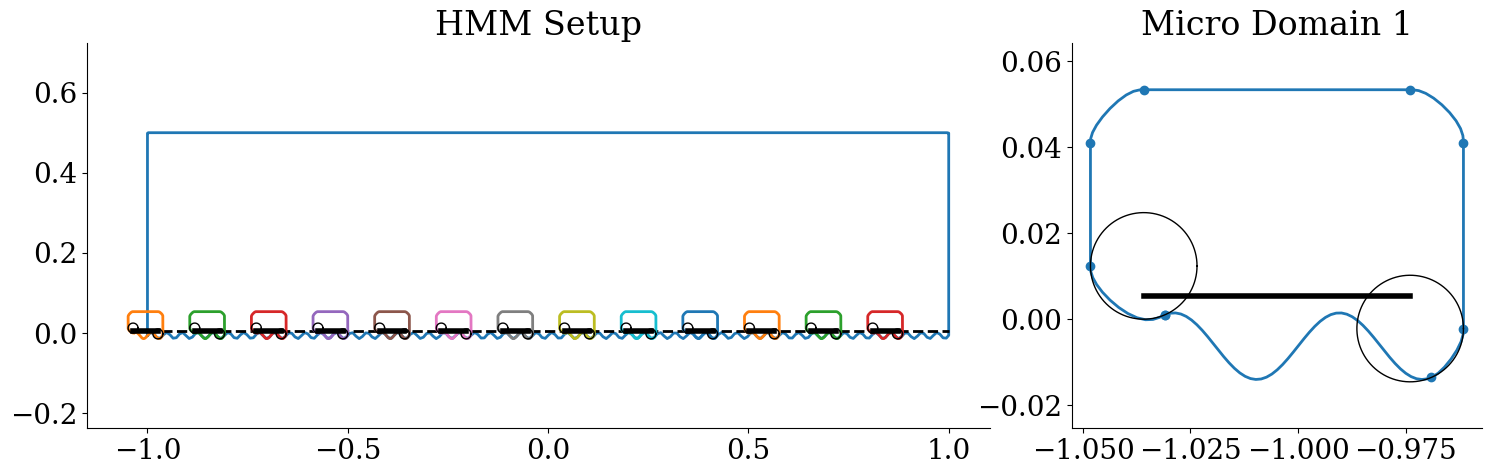

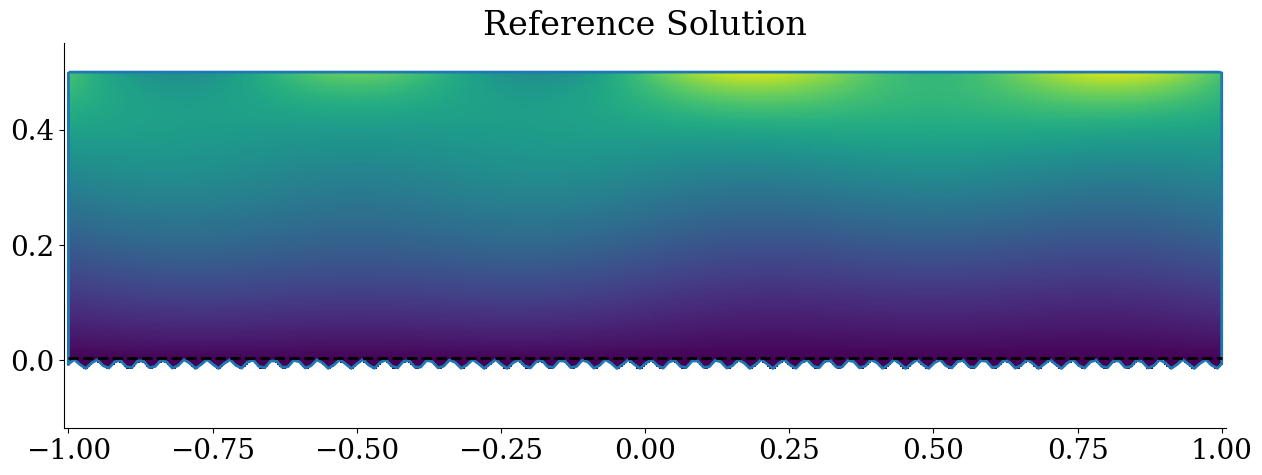

In [31]:
logger = EventTracker() # Log time

tol = 1e-10
xDim = 51
yDim = 51
nMic = 13#7 #freq_g*2+1#2*(round(Lx/(30*eps)) // 2) + 1 # 15 # 15 #nMic*2 +1
yDim_reduce = 15#51
xDim_reduce = 15#51
width = 8*eps #5*eps #3
height = width*0.8 #3
n_refine = 0
linePos = 0.03

#################
# Macro problem
#################
print(data)
data.dom = [dom[0], [linePos*height+dom[1][0], dom[1][1]]] # Make sure line is bottom of domain

# Mean
#macro = StokesMacProb(data, lambda x, a: lambda y: np.mean(a)*np.ones_like(y))
#macro_0 = StokesMacProb(data_0, lambda x,a: lambda y: np.mean(a)*np.ones_like(y))
      
# FFT                  
macro = StokesMacProb(data, lambda x, a: fft_interp(x, a, dom=dom[0]))
macro_0 = StokesMacProb(data_0, lambda x, a: fft_interp(x, a, dom=dom[0])) # For comparison
###################
# Micro problems
###################


#data.dom = [dom[0], [linePos*height, dom[1][1]]]
#xPos = np.linspace(dom[0][0]+4*eps, dom[0][1]-4*eps, nMic)-2*eps
xPos = np.linspace(dom[0][0], dom[0][1], nMic+1)[1:] - width/2 - Lx / nMic
micros = [StokesMicProb(data, x, width, height, linePos=linePos, deg_project=8, logger=logger, 
                        n_refine=n_refine, xDim_reduce=xDim_reduce, yDim_reduce=yDim_reduce) for x in xPos]

###################
# Hmm problem.
conv_checker = ConvergenceChecker(macro, micros, tol=tol)
hmm_prob = StokesHMMProblem(macro, micros, data, convergence_checker=conv_checker)

###################
## PLOT ##
plt.figure(figsize=(18,5))


plt.subplot2grid((1, 3), (0, 0), 1, 2)
plt.title("HMM Setup")
hmm_prob.plot(plt.gca())
plt.axis("Equal")
remove_top_right_axes(plt.gca())

plt.subplot2grid((1, 3), (0, 2), 1, 1)
plt.title("Micro Domain 1")
micros[0].plot(plt.gca(), showsegments=True)
plt.axis("equal")
remove_top_right_axes(plt.gca())

# Plot

vmin, vmax= 0, .7
plt.figure(figsize=(15,5))
plt.title("Reference Solution")
plt.pcolormesh(X, Y, Uc, vmin=vmin, vmax=vmax)
data.plot(plt.gca(), npts=800)
plt.axis("equal")
remove_top_right_axes(plt.gca())
plt.ylim([dom[1][0]-0.12, dom[1][1]+0.05])



## Solving using HMM iterations

To solve the problem, we make use of a sequence of micro solvers, as well as a micro solver.

In [32]:
macro_solver = MacroSolver(xDim, yDim, tol=tol, logger=logger)
macro_solver_0 = MacroSolver(xDim, yDim, tol=tol)

print("Deep precomputing...")
deep_micro_solvers = [DeepMicroSolver(m, net, net_settings, logger=logger, tol=tol) for m in micros]

class CountCallback():
    def __init__(self):
        self.count = 0
    def __call__(self, *args):
        self.count += 1
counters = [CountCallback() for m in micros]
    
print("Classic precomputing...")
micro_solvers = [MicroSolver(m, logger=logger, tol=tol, callback=c) for m, c in zip(micros, counters)]
print("Done")

deep_hmm_solver = IterativeHMMSolver(macro_solver, deep_micro_solvers)
hmm_solver = IterativeHMMSolver(macro_solver, micro_solvers)

class Callback():
    def __init__(self, macro):
        self.N = 100
        self.x = np.linspace(0,1,self.N)
        self.macro = macro
        self.current_alpha = macro.alpha(self.x)
        self.diff = []
        self.micro_errors = []
    
    def __call__(self, it, macro_sol, micro_sols):
        errors = []
        for deep_micro, micro, prob in zip(deep_micro_solvers, micro_solvers, micros):
            deep_sol = deep_micro.solve(prob)
            sol = micro.solve(prob)
            errors.append(np.abs((deep_sol.alpha - sol.alpha) / sol.alpha))
            #r_true, _ = micro.geom.precompute_line_avg(derivative=0)
            #t1, _ = micro.geom.grid.get_grid_and_weights()
            #r_true_t = interp1d(t1, r_true, kind="cubic")(micro.t)
            #errors.append(np.linalg.norm(micro.r - r_true_t)/np.linalg.norm(r_true_t))
        self.micro_errors.append(errors)
        self.previous_alpha = self.current_alpha
        self.current_alpha = self.macro.alpha(self.x)
        self.diff.append(np.linalg.norm(self.previous_alpha - self.current_alpha) / self.N**0.5)
       
debug_cb = Callback(macro)

print([c.count for c in counters])

Deep precomputing...


Classic precomputing...
Done
[30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30]


error in r: 1.24e-01, in dr: 1.01e-01
error in r: 1.24e-01, in dr: 1.01e-01
error in r: 1.24e-01, in dr: 1.01e-01
error in r: 1.24e-01, in dr: 1.01e-01
error in r: 1.24e-01, in dr: 1.01e-01
error in r: 1.24e-01, in dr: 1.01e-01
error in r: 1.24e-01, in dr: 1.01e-01
error in r: 1.24e-01, in dr: 1.01e-01
error in r: 1.24e-01, in dr: 1.01e-01
error in r: 1.24e-01, in dr: 1.01e-01
error in r: 1.24e-01, in dr: 1.01e-01
error in r: 1.24e-01, in dr: 1.01e-01
error in r: 1.24e-01, in dr: 1.01e-01


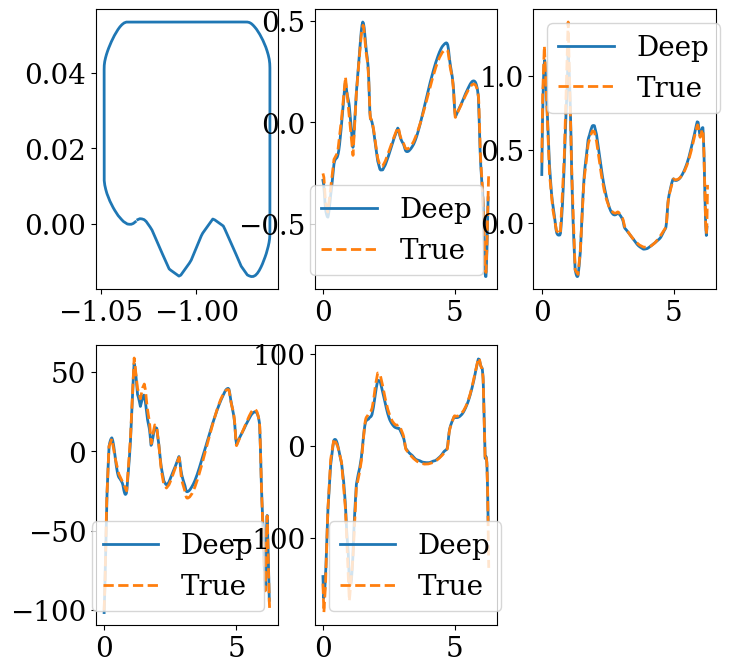

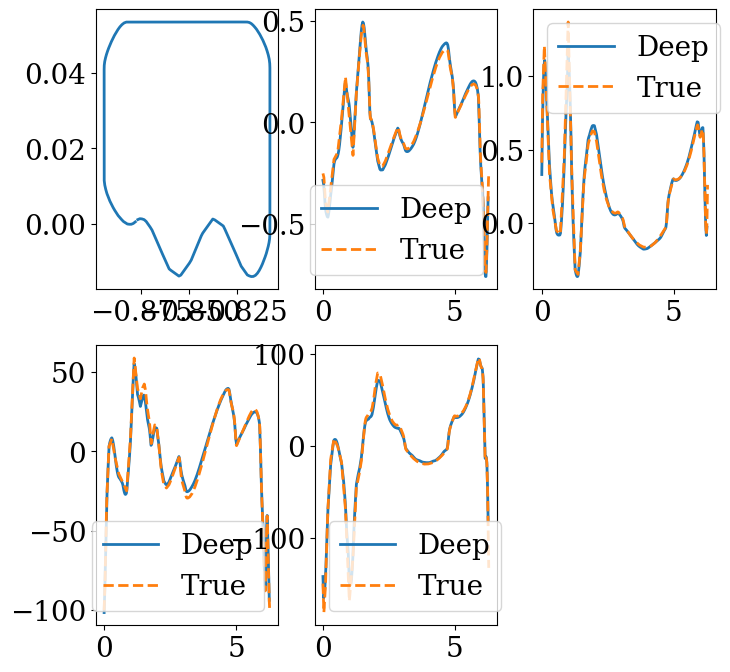

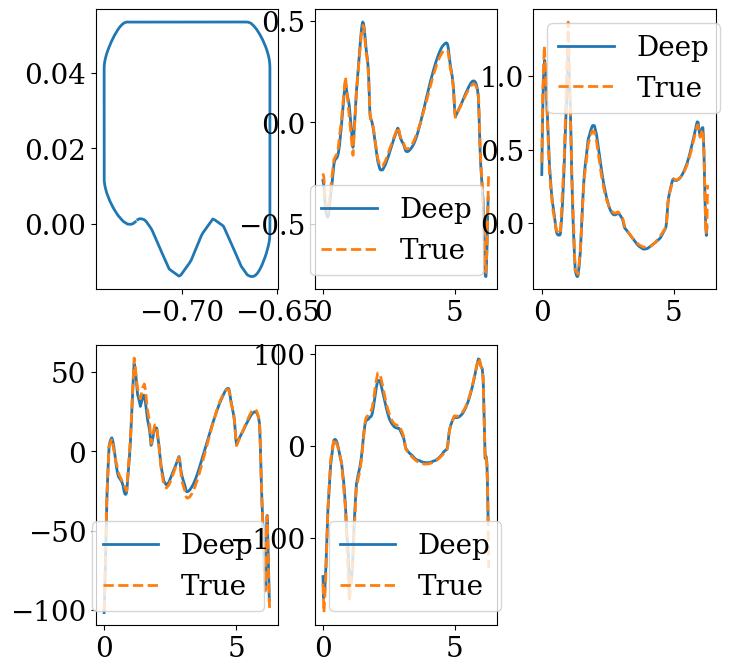

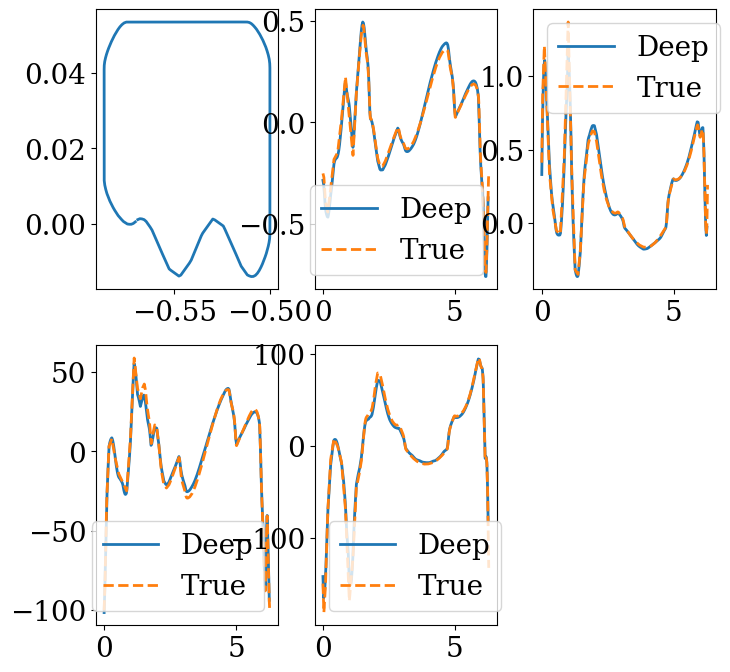

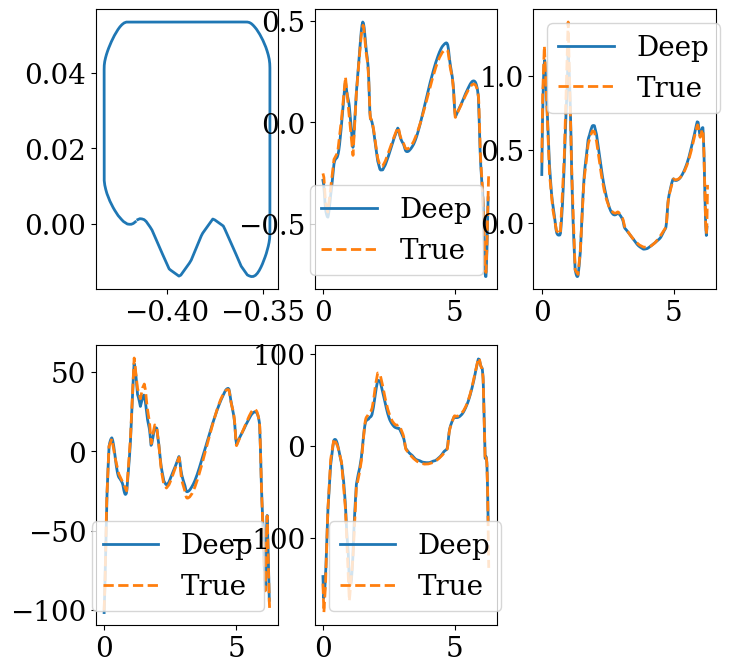

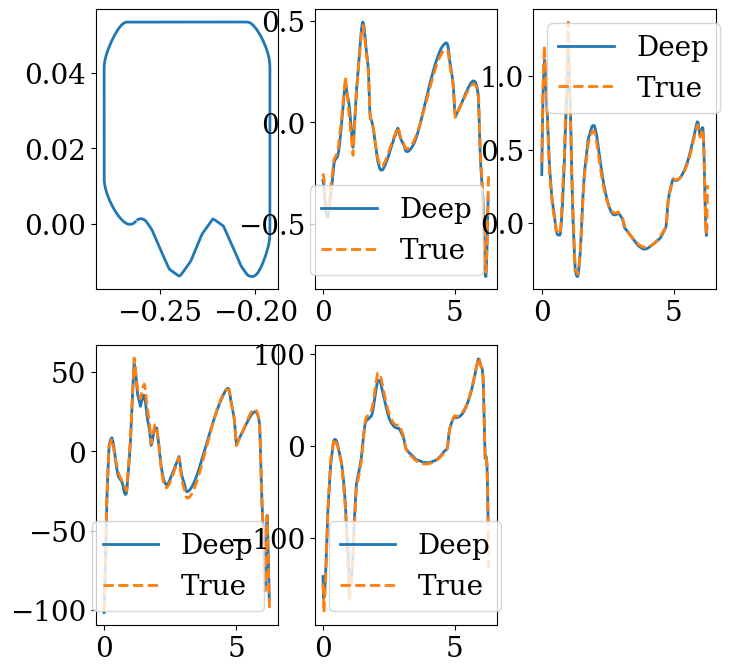

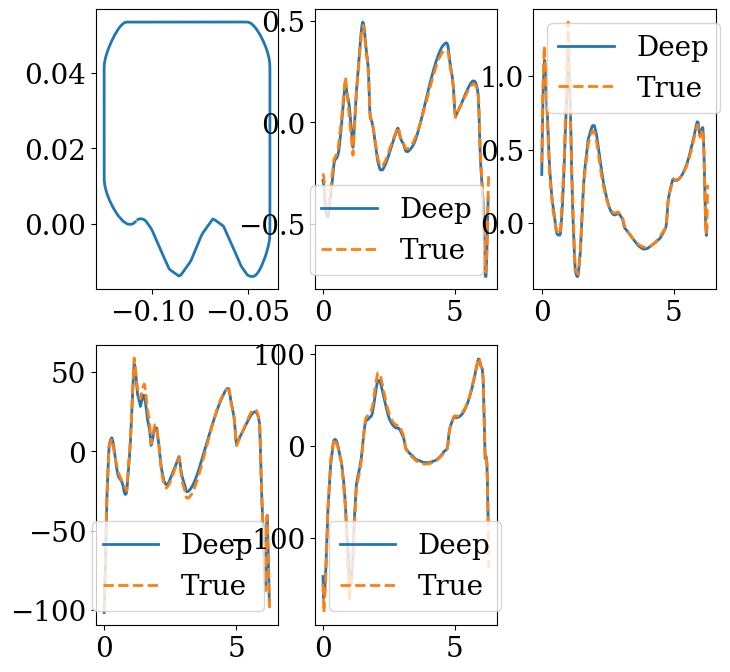

In [33]:
def interp_periodic(t, y, tval):
    t = np.concatenate([[t[-1]-np.pi*2], t, [t[0] + np.pi*2]])
    y = np.concatenate([[y[-1]], y, [y[0]]])
    return interp1d(t, y, kind="cubic")(tval)

num_mic = len(micro_solvers)
sqrt_num_mic = int(np.ceil(num_mic**0.5))
for i, (s, self) in enumerate(zip(micro_solvers, deep_micro_solvers)):
    #print(list(ds.__dict__.keys()))
    self.r_true, self.avg_true = self.geom.precompute_line_avg(derivative=0)
    self.dr_true, self.davg_true = self.geom.precompute_line_avg(derivative=1)
    t1, _ = self.geom.grid.get_grid_and_weights()
    r_true_t = interp_periodic(t1, self.r_true, self.t)
    dr_true_t = interp_periodic(t1, self.dr_true, self.t)
    
    #plt.plot(self.t, r_true_t)
    #plt.plot(self.t, self.r)
    
    
    #plt.figure(1, figsize=(7,15))
    
    #plt.subplot(2*sqrt_num_mic, sqrt_num_mic, i+1)
    #plt.plot(self.t, np.abs(r_true_t))
    #plt.plot(self.t, np.abs(self.r), '--')
    #plt.plot(self.t, np.abs(self.r - r_true_t), ':')
    
    #plt.subplot(2*sqrt_num_mic, sqrt_num_mic, sqrt_num_mic**2 + i + 1)
    #plt.plot(self.t, np.abs(dr_true_t))
    #plt.plot(self.t, np.abs(self.dr), '--')
    #plt.plot(self.t, np.abs(self.dr - dr_true_t), ':')
    print(f"error in r: {np.linalg.norm(self.r - r_true_t)/np.linalg.norm(r_true_t):.2e}, " +\
           f"in dr: {np.linalg.norm(self.dr - dr_true_t)/np.linalg.norm(dr_true_t):.2e}")
#plt.plot(ds.dr[::2].imag)
#lt.plot(ds.dr_true.imag)
#deep_micro_solvers[0].plot()  

for i in range(7):#len(micro_solvers)):
    plt.figure()
    deep_micro_solvers[i].plot()

In [34]:
macro_guess = macro_solver_0.solve(macro_0)
print("Deep HMM Solver...")
(deep_macro_sol, deep_micro_sols) = deep_hmm_solver.solve(hmm_prob, macro_guess=macro_guess, 
                                           callback=debug_cb, verbose=True, maxiter=3, tol=tol, logger=logger)
print("\nDone")

deep_diff = debug_cb.diff
debug_cb.diff = []
debug_cb.micro_errors = []

print("Classic HMM Solver...")
macro_guess = macro_solver_0.solve(macro_0)
(macro_sol, micro_sols) = hmm_solver.solve(hmm_prob, macro_guess=macro_guess, 
                                           callback=debug_cb, verbose=True, maxiter=3, tol=tol, logger=logger)
print("\nDone")





Deep HMM Solver...


Step 2/3
Done
Classic HMM Solver...
Step 2/3
Done


### Convergence and computation time

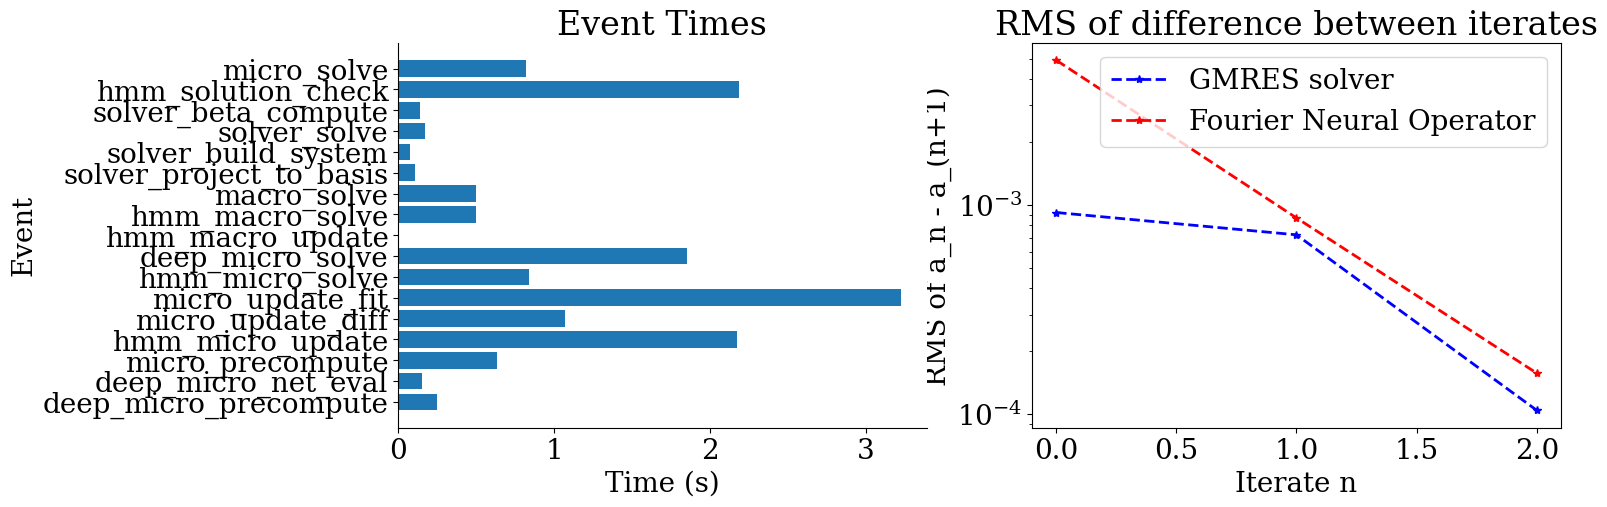

In [35]:
plt.figure(figsize=(15,5))
plt.subplot(122)
plt.title("RMS of difference between iterates")
plt.semilogy(debug_cb.diff, 'b*--', label='GMRES solver')
plt.semilogy(deep_diff, 'r*--', label='Fourier Neural Operator')

plt.legend()
plt.xlabel("Iterate n")
plt.ylabel("RMS of a_n - a_(n+1)")

plt.subplot(121)
logger.barplot_logs(plt.gca())


## Accuracy
We use the reference solver data to construct a piecewise linear interpolation. Also, the micro data is used to construct a set of full solutions to the velocity field in the micro problems for visualisation purposes.

/home/emastr/anaconda3/envs/pimlenv/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/emastr/anaconda3/envs/pimlenv/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<Figure size 800x800 with 0 Axes>

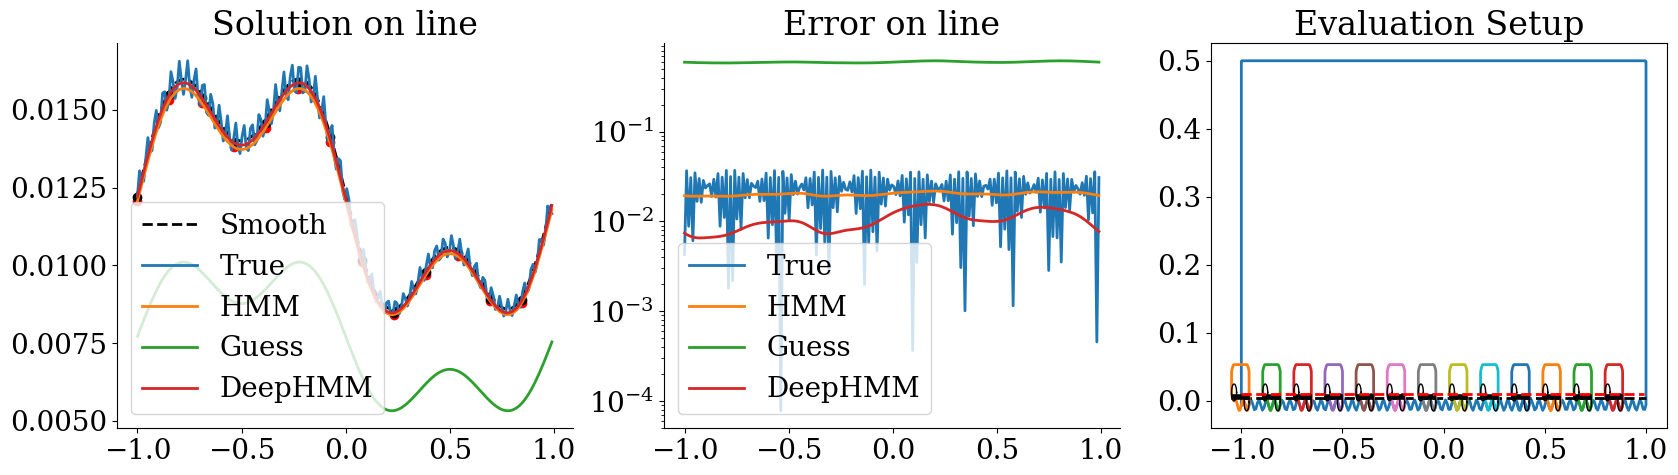

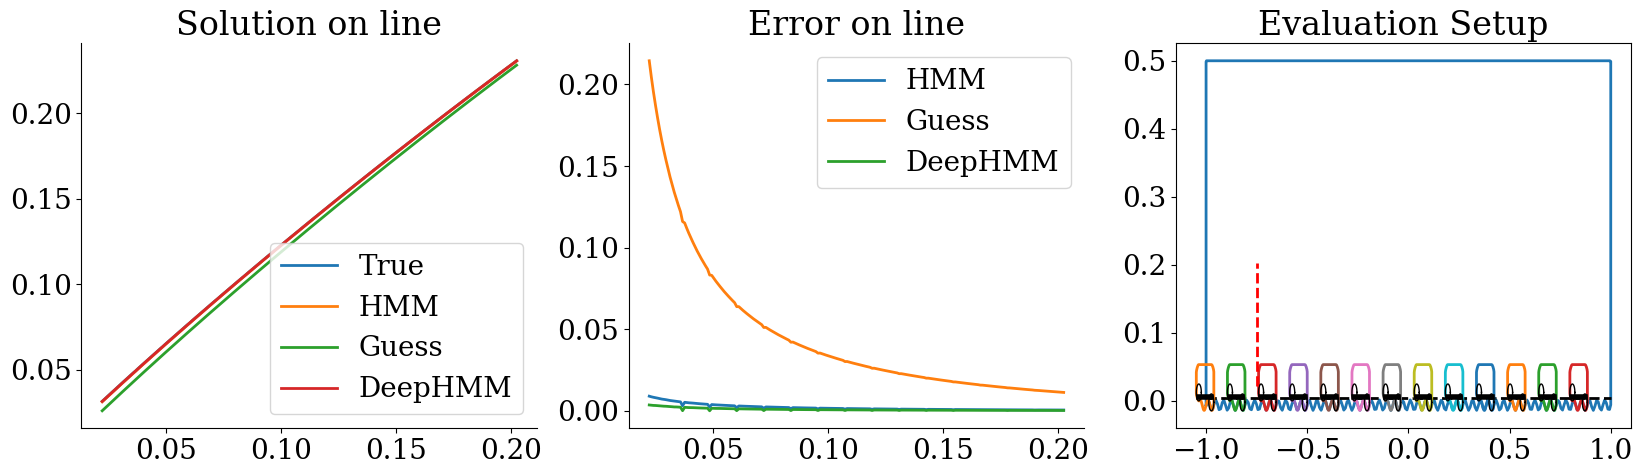

In [36]:
macro_guess = macro_solver.solve(macro_0)


def error(x, y):
    #return np.linalg.norm(x - y) / np.linalg.norm(x)
    return np.max(np.abs(x-y))/np.max(np.abs(x))

# plot a line at y = 0.03
xval = np.linspace(dom[0][0],dom[0][1], 200)[:-1]
yval = np.ones_like(xval)*0.01
basis = ScaleShiftedBasis.fromFunctionInDomain(lambda x: pwlerp(x,yval), dom[0], FourBasis, dim=len(yval)).change_dim(nMic*2+1)
smooth = lambda x, y: basis(x)
funcs = [smooth, pwlerp, macro_sol.u, macro_guess.u, deep_macro_sol.u]
title = ["Smooth", "True", "HMM", "Guess", "DeepHMM"]


# Plot solutions on horizontal line

plt.figure()
plot_line(xval, yval, funcs, title, hmm_prob.plot, axis='x')
plt.subplot(1,3,2)
plt.yscale("log")

plt.subplot(1,3,1)
plt.scatter(xPos+width/2, macro_sol.u(xPos+width/2, yval[0]*np.ones_like(xPos)), color='r')
plt.scatter(xPos+width/2, deep_macro_sol.u(xPos+width/2, yval[0]*np.ones_like(xPos)), color='k')

# plot a vertical line in between the first and second micro problems
funcs.pop(0)
title.pop(0)
yval = np.linspace(dom[1][0]+0.02, dom[1][0] + 0.2, 200)
xval = -0.75*np.ones_like(yval) #0.5*(xPos[nMic//2] + xPos[nMic//2+1]) * np.ones_like(yval)

idx = np.arange(len(xval))
s = 13
r = 9

plot_line(xval[idx % s != r], yval[idx % s != r], funcs, title, hmm_prob.plot, axis='y')
#plot_line(xval, yval, funcs, title, hmm_prob.plot, axis='y')

In [37]:

xlist = np.linspace(dom[0][0], dom[0][1], 400)[:-1]
ylist = np.linspace(dom[1][0], dom[1][0] + 0.18, 20)
X, Y = np.meshgrid(xlist, ylist)


method_names = ["True", "Smooth", "Naive", "HMM, FNO", "HMM, GMRES"]
method_funcs = [pwlerp, smooth, macro_guess.u, deep_macro_sol.u, macro_sol.u]
methods = {method: np.reshape(u(X.flatten(), Y.flatten()), X.shape) for method, u in zip(method_names, method_funcs)}

ones = np.ones_like(xlist)
methods["Smooth"] = np.array([ScaleShiftedBasis.fromFunctionInDomain(lambda x: pwlerp(x, y*ones), dom[0], FourBasis, dim=len(ones)).change_dim(nMic*2+1)(xlist) for y in ylist])
#print([m.shape for m in methods.values()])
#print(ScaleShiftedBasis.fromFunctionInDomain(lambda x: pwlerp(x, 0.1*np.ones_like(x)), dom[0], FourBasis, dim=len(x)).change_dim(nMic*2+1)(xval).shape, print(xval.shape))

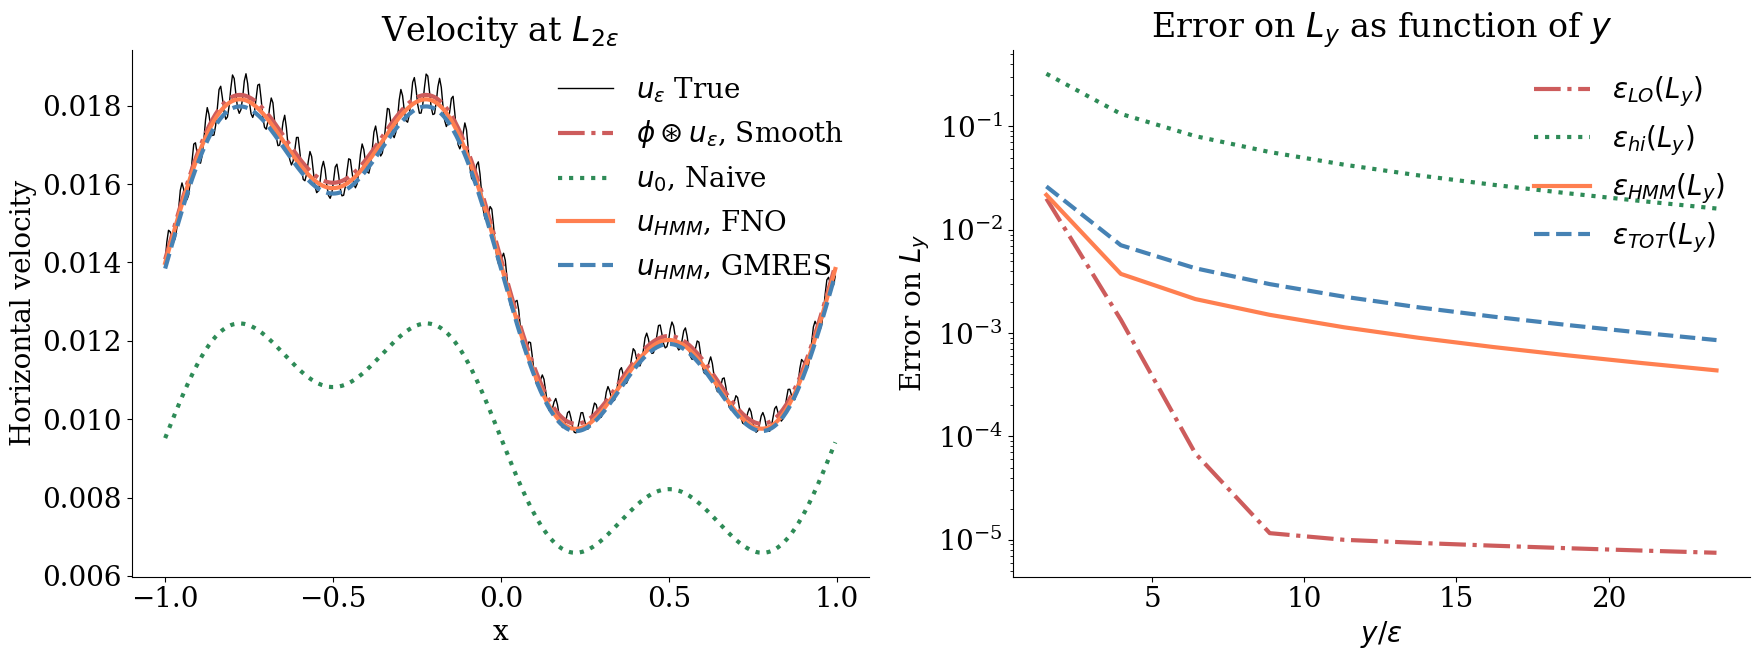

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.figsize'] = (8,8)
matplotlib.rcParams['font.size'] = 20
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['lines.linewidth'] = 2

styles = {method: style for method, style in zip(method_names, ['-', '-.', ':', '-', '--'])}
linewidths = {method: lw for method, lw in zip(method_names, [1, 3, 3, 3, 3])}
color_range = ["black", "indianred", "seagreen", "coral", "steelblue"]
colors = {key: color_range[i] for i, key in enumerate(method_names)}
i = 1#10

plt.figure(figsize=(18,7))

ax = plt.subplot(1,2,1)

for key, lab in zip(method_names, ["$u_{\\epsilon}$ True", "$\\phi\\circledast u_\\epsilon$, Smooth", \
                                    "$u_0$, Naive", "$u_{HMM}$, FNO", "${u}_{HMM}$, GMRES"]):
    plt.plot(xlist, methods[key][i], linestyle=styles[key], color=colors[key], label=lab, linewidth=linewidths[key])

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.title("Velocity at $L_{" + f"{ylist[i]/eps:.0f}" + "\\epsilon}$")
plt.xlabel("x")
plt.ylabel("Horizontal velocity")

#plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])

plt.legend(frameon=False, loc='upper right')

ax = plt.subplot(1,2,2)

# Mean square Relative error as function of distance from circle

compare = "True"

errors = {key: np.array([(np.mean((methods[key][i]-methods[compare][i])**2)/np.mean(methods[compare][i]**2))**0.5 for i in range(len(ylist))]) for key in methods.keys()}

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

for key, lab in zip(methods.keys(), ["True", "$\\varepsilon_{LO}(L_y)$", "$\\varepsilon_{hi}(L_y)$", \
                                    "$\\varepsilon_{HMM}(L_y)$", "$\\varepsilon_{TOT}(L_y)$"]):
    if key != compare:
        plt.plot((ylist/eps)[1::2], errors[key][1::2], linestyle=styles[key], color=colors[key], label=lab, linewidth=linewidths[key])
plt.legend()
plt.legend(frameon=False, loc='upper right')

plt.title("Error on $L_y$ as function of $y$")
plt.yscale('log')
plt.xlabel("$y/\\epsilon$")
plt.ylabel("Error on $L_y$")
#plt.legend(frameon=False)
plt.tight_layout()
plt.gcf().savefig(f"{figures_dir}pipe_error.pdf", bbox_inches='tight')

## Visualisation - 2D plots

{'f': <function StokesData.load_from_matlab.<locals>.<lambda> at 0x7f36dc32c540>, 'df': <function StokesData.load_from_matlab.<locals>.<lambda> at 0x7f359d9e4fe0>, 'ddf': <function StokesData.load_from_matlab.<locals>.<lambda> at 0x7f359d8f4fe0>, 'g': <function StokesData.load_from_matlab.<locals>.<lambda> at 0x7f359d8f5260>, 'dom': [[-1.0, 1.0], [0.0038093773187911446, 0.5]], 'width': 2.0, 'height': 0.4976772089519566}


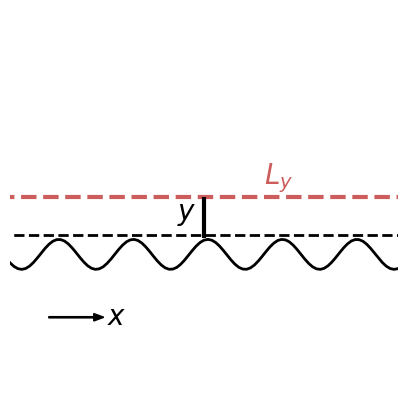

In [39]:
matplotlib.rcParams['figure.figsize'] = (8,8)
matplotlib.rcParams['font.size'] = 20
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['lines.linewidth'] = 2
plt.figure(figsize=(5,5))
#dl.plot(mesh, color='black', linewidth=0.1)
remove_axes(plt.gca())
plt.axis("equal")
hmm_prob.data.plot(plt.gca(), npts=4000, color="black")
print(hmm_prob.data.__dict__)
plt.hlines([3*eps], dom[0][0], dom[0][1], color='indianred', linestyle = '--', linewidth=3)
plt.vlines([xPos[nMic//2]], dom[1][0], 3*eps, color='black', linestyle = '-', linewidth=3)
plt.xlim([xPos[nMic//2]-0.1, xPos[nMic//2]+0.1])
plt.ylim([dom[1][0]-3*eps, 8*eps])
plt.text(xPos[nMic//2]+4*eps, 3.9*eps, "$L_y$", color="indianred")
plt.text(xPos[nMic//2]-1.8*eps, 1.5*eps, "$y$", color="black")
plt.arrow(xPos[nMic//2]-0.08, -5*eps, 3*eps, 0, color='black', head_width=eps/2, head_length=eps/1.5, width=eps/12)
#plt.arrow(xPos[nMic//2]-0.08, 8*eps, 0, 3*eps, color='black', head_width=eps/2, head_length=eps/1.5, width=eps/12)
plt.text(xPos[nMic//2]-0.05, -5*eps-0.5*eps, "$x$", color="black")


plt.gcf().savefig(f"{figures_dir}pipe_domain.pdf", bbox_inches='tight')


Verifying derivatives